In [1]:
# Cell 1 - Load, filter, and validate the primary dataset
import importlib
from pathlib import Path
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D
import numpy as np

# Optional binary backends are not required for this analysis.
for optional_backend in ("pyarrow", "numexpr", "bottleneck"):
    sys.modules[optional_backend] = None
pd = importlib.import_module("pandas")


def find_phase1_dir(start: Path) -> Path:
    """Locate the phase1 directory."""
    relative_input = Path(
        "results/simplex_projection/summary/processed_simplex_summary.csv"
    )
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / relative_input).is_file():
            return candidate
        if (candidate / "phase1" / relative_input).is_file():
            return candidate / "phase1"
    raise FileNotFoundError("Could not locate the phase1 directory.")


def require(condition: bool, message: str) -> None:
    """Raise a clear integrity error."""
    if not condition:
        raise ValueError(message)


PHASE1_DIR = find_phase1_dir(Path.cwd())
INPUT_PATH = (
    PHASE1_DIR
    / "results/simplex_projection/summary/processed_simplex_summary.csv"
)
OUTPUT_DIR = PHASE1_DIR / "outputs" / "prediction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPRESENTATION = "Processed"
WINDOW_SIZE_S = 60
N_SESSIONS_EXPECTED = 20
STATES = ("Awake", "Drowsy")
M_FINAL = 8
TAU_FINAL_S = 0.16
EXPECTED_HORIZONS = np.array(
    [
        0.04, 0.08, 0.12, 0.16, 0.20, 0.28, 0.40, 0.60, 0.80,
        1.00, 1.20, 1.60, 2.00, 2.40, 2.80, 3.20, 3.60, 4.00,
    ]
)

raw = pd.read_csv(INPUT_PATH)
required_columns = {
    "session", "state", "representation", "window_size_s",
    "horizon_seconds", "median_cc", "median_nrmse", "n_windows",
}
missing_columns = required_columns - set(raw.columns)
require(not missing_columns, f"Missing columns: {sorted(missing_columns)}")

scope_mask = (
    raw["representation"].astype(str).str.casefold().eq(
        REPRESENTATION.casefold()
    )
    & pd.to_numeric(raw["window_size_s"], errors="coerce").eq(
        WINDOW_SIZE_S
    )
    & raw["state"].isin(STATES)
)
qc_candidates = [
    column
    for column in ("included", "include", "is_valid", "qc_pass")
    if column in raw.columns
]
require(len(qc_candidates) <= 1, "Multiple inclusion flags found.")
if qc_candidates:
    qc_values = raw[qc_candidates[0]].astype(str).str.strip().str.casefold()
    valid_values = {"true", "1", "yes", "included", "pass"}
    invalid_values = {"false", "0", "no", "excluded", "fail"}
    require(
        qc_values.isin(valid_values | invalid_values).all(),
        "Unrecognized inclusion flag.",
    )
    scope_mask &= qc_values.isin(valid_values)
primary = raw.loc[scope_mask].copy()
numeric_columns = [
    "window_size_s", "horizon_seconds", "median_cc",
    "median_nrmse", "n_windows",
]
primary[numeric_columns] = primary[numeric_columns].apply(
    pd.to_numeric, errors="coerce"
)

key = ["session", "state", "horizon_seconds"]
require(len(primary) > 0, "The frozen filter returned no rows.")
require(set(primary["state"]) == set(STATES), "State coverage is incomplete.")
require(
    primary["session"].nunique() == N_SESSIONS_EXPECTED,
    f"Expected {N_SESSIONS_EXPECTED} sessions.",
)
require(not primary.duplicated(key).any(), "Duplicate primary keys found.")
require(primary[numeric_columns].notna().all().all(), "Missing values found.")
require(
    np.isfinite(primary[["median_cc", "median_nrmse"]]).all().all(),
    "Non-finite prediction metrics found.",
)
observed_horizons = np.sort(primary["horizon_seconds"].unique())
require(
    len(observed_horizons) == len(EXPECTED_HORIZONS)
    and np.allclose(observed_horizons, EXPECTED_HORIZONS),
    "The horizon grid differs from the frozen scope.",
)
cell_counts = primary.groupby(["session", "state"])["horizon_seconds"].nunique()
require(
    cell_counts.eq(len(EXPECTED_HORIZONS)).all(),
    "A session-state cell has incomplete horizons.",
)
window_variation = primary.groupby(["session", "state"])["n_windows"].nunique()
require(window_variation.eq(1).all(), "Window counts vary by horizon.")
require(primary["n_windows"].gt(0).all(), "Invalid window count found.")
state_window_counts = (
    primary.groupby(["session", "state"])["n_windows"]
    .first().groupby("state").sum().reindex(STATES).astype(int)
)
print(
    "Prediction primary dataset\n"
    f"{REPRESENTATION}, {WINDOW_SIZE_S} s; m = {M_FINAL}; "
    f"tau = {TAU_FINAL_S:.2f} s\n"
    f"Sessions: {primary['session'].nunique()}/{N_SESSIONS_EXPECTED}\n"
    f"Awake windows: {state_window_counts['Awake']:,}\n"
    f"Drowsy windows: {state_window_counts['Drowsy']:,}\n"
    f"Prediction horizons: {len(observed_horizons)}\n"
    f"Horizon range: {observed_horizons.min():.2f}-"
    f"{observed_horizons.max():.2f} s\nIntegrity: PASS"
)


Prediction primary dataset
Processed, 60 s; m = 8; tau = 0.16 s
Sessions: 20/20
Awake windows: 596
Drowsy windows: 305
Prediction horizons: 18
Horizon range: 0.04-4.00 s
Integrity: PASS


In [2]:
# Cell 2 - Construct session curves and across-session summaries
session_curves = (
    primary[
        ["session", "state", "horizon_seconds", "median_cc",
         "median_nrmse", "n_windows"]
    ]
    .sort_values(["state", "session", "horizon_seconds"])
    .reset_index(drop=True)
)
curve_summary = (
    session_curves.groupby(["state", "horizon_seconds"], as_index=False)
    .agg(
        n_sessions=("session", "nunique"),
        cc_median=("median_cc", "median"),
        cc_q25=("median_cc", lambda x: x.quantile(0.25)),
        cc_q75=("median_cc", lambda x: x.quantile(0.75)),
        cc_min=("median_cc", "min"),
        cc_max=("median_cc", "max"),
        nrmse_median=("median_nrmse", "median"),
        nrmse_q25=("median_nrmse", lambda x: x.quantile(0.25)),
        nrmse_q75=("median_nrmse", lambda x: x.quantile(0.75)),
        nrmse_min=("median_nrmse", "min"),
        nrmse_max=("median_nrmse", "max"),
    )
)
require(
    curve_summary["n_sessions"].eq(N_SESSIONS_EXPECTED).all(),
    "Not all sessions span the full horizon range.",
)
contribution_counts = (
    curve_summary.pivot(
        index="horizon_seconds", columns="state", values="n_sessions"
    ).reindex(columns=STATES).astype(int)
)
print("Sessions contributing at each horizon/state")
print(contribution_counts.to_string())
print("\nAll 20 sessions contribute throughout: PASS")


Sessions contributing at each horizon/state
state            Awake  Drowsy
horizon_seconds               
0.04                20      20
0.08                20      20
0.12                20      20
0.16                20      20
0.20                20      20
0.28                20      20
0.40                20      20
0.60                20      20
0.80                20      20
1.00                20      20
1.20                20      20
1.60                20      20
2.00                20      20
2.40                20      20
2.80                20      20
3.20                20      20
3.60                20      20
4.00                20      20

All 20 sessions contribute throughout: PASS


In [3]:
# Cell 3 - Summarize interpretable horizons and endpoint directions
def nearest_horizon(target: float, horizons: np.ndarray) -> float:
    """Select the nearest horizon, preferring the shorter tie."""
    return float(min(horizons, key=lambda value: (abs(value - target), value)))


requested_horizons = (0.04, 0.50, 1.00, 2.00, 4.00)
selected_rows = []
for target in requested_horizons:
    actual = nearest_horizon(target, observed_horizons)
    rows = curve_summary.loc[
        np.isclose(curve_summary["horizon_seconds"], actual)
    ].copy()
    rows.insert(1, "requested_horizon_s", target)
    selected_rows.append(rows)
selected_summary = pd.concat(selected_rows, ignore_index=True)
selected_summary["state"] = pd.Categorical(
    selected_summary["state"], categories=STATES, ordered=True
)
selected_summary = selected_summary.sort_values(
    ["state", "requested_horizon_s"]
).reset_index(drop=True)
short_horizon = float(observed_horizons.min())
long_horizon = float(observed_horizons.max())
endpoint_values = session_curves.loc[
    session_curves["horizon_seconds"].isin([short_horizon, long_horizon])
]
endpoint_wide = endpoint_values.pivot(
    index=["session", "state"], columns="horizon_seconds",
    values=["median_cc", "median_nrmse"],
)
require(endpoint_wide.notna().all().all(), "Endpoint pairs are incomplete.")
endpoint_changes = endpoint_wide.index.to_frame(index=False)
endpoint_changes["cc_decay"] = (
    endpoint_wide[("median_cc", long_horizon)].to_numpy()
    - endpoint_wide[("median_cc", short_horizon)].to_numpy()
)
endpoint_changes["nrmse_change"] = (
    endpoint_wide[("median_nrmse", long_horizon)].to_numpy()
    - endpoint_wide[("median_nrmse", short_horizon)].to_numpy()
)
report_columns = [
    "state", "requested_horizon_s", "horizon_seconds",
    "cc_median", "cc_q25", "cc_q75", "nrmse_median",
    "nrmse_q25", "nrmse_q75", "n_sessions",
]
print("Selected-horizon descriptive summary")
print(
    selected_summary[report_columns].to_string(
        index=False, float_format=lambda value: f"{value:.3f}"
    )
)
print("\nEndpoint direction consistency")
for state in STATES:
    values = endpoint_changes.loc[endpoint_changes["state"].eq(state)]
    print(
        f"{state}: CC decay {values['cc_decay'].lt(0).sum()}/{len(values)}; "
        f"NRMSE increase {values['nrmse_change'].gt(0).sum()}/{len(values)}"
    )


Selected-horizon descriptive summary
 state  requested_horizon_s  horizon_seconds  cc_median  cc_q25  cc_q75  nrmse_median  nrmse_q25  nrmse_q75  n_sessions
 Awake                0.040            0.040      0.966   0.961   0.971         0.258      0.238      0.278          20
 Awake                0.500            0.400      0.901   0.877   0.915         0.433      0.402      0.481          20
 Awake                1.000            1.000      0.759   0.713   0.804         0.655      0.595      0.701          20
 Awake                2.000            2.000      0.535   0.492   0.576         0.862      0.828      0.888          20
 Awake                4.000            4.000      0.216   0.178   0.291         1.019      0.996      1.034          20
Drowsy                0.040            0.040      0.962   0.957   0.966         0.274      0.260      0.289          20
Drowsy                0.500            0.400      0.886   0.873   0.907         0.465      0.421      0.486          20
Dro

/tmp/ipykernel_38968/1341436892.py:6: RuntimeWarning: Times New Roman is unavailable; using Liberation Serif. Install Times New Roman before final manuscript export.
  warnings.warn(


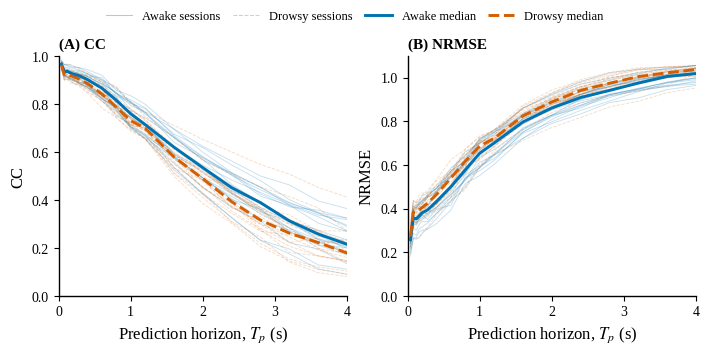

In [4]:
# Cell 4 - Create the publication figure
required_font = "Times New Roman"
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
active_font = required_font if required_font in available_fonts else "Liberation Serif"
if active_font != required_font:
    warnings.warn(
        "Times New Roman is unavailable; using Liberation Serif. "
        "Install Times New Roman before final manuscript export.",
        RuntimeWarning,
        stacklevel=1,
    )
mpl.rcParams.update(
    {
        "font.family": active_font,
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.linewidth": 1.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.fontsize": 10,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.transparent": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "mathtext.fontset": "stix",
    }
)
state_colors = {"Awake": "#0072B2", "Drowsy": "#D55E00"}
state_styles = {"Awake": "-", "Drowsy": "--"}
panel_specs = (
    ("median_cc", "cc_median", "CC", (0.0, 1.0),
     np.linspace(0.0, 1.0, 6), "(A) CC"),
    ("median_nrmse", "nrmse_median", "NRMSE", (0.0, 1.1),
     np.arange(0.0, 1.01, 0.2), "(B) NRMSE"),
)


def save_prediction_figure(fig: mpl.figure.Figure, stem: str) -> None:
    """Save vector masters and a 600-dpi raster copy."""
    path = OUTPUT_DIR / stem
    fig.savefig(path.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(path.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(path.with_suffix(".png"), dpi=600, bbox_inches="tight")


def plot_prediction_panel(
    ax: mpl.axes.Axes,
    metric: str, summary_metric: str, ylabel: str, ylim: tuple[float, float],
    yticks: np.ndarray, panel_label: str,
) -> None:
    """Plot both states and retain every session curve."""
    for state in STATES:
        state_curves = session_curves.loc[session_curves["state"].eq(state)]
        for _, session_data in state_curves.groupby("session", sort=True):
            ax.plot(
                session_data["horizon_seconds"],
                session_data[metric],
                color=state_colors[state],
                linestyle=state_styles[state],
                linewidth=0.65,
                alpha=0.22,
                zorder=1,
            )
        state_summary = curve_summary.loc[curve_summary["state"].eq(state)]
        ax.plot(
            state_summary["horizon_seconds"],
            state_summary[summary_metric],
            color=state_colors[state],
            linestyle=state_styles[state],
            linewidth=2.1,
            zorder=3,
        )
    ax.set_xlim(0.0, 4.0)
    ax.set_ylim(*ylim)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_yticks(yticks)
    ax.set_xlabel(r"Prediction horizon, $T_p$ (s)")
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(False)
    ax.text(
        0.0, 1.02, panel_label, transform=ax.transAxes, ha="left",
        va="bottom", fontweight="bold",
    )


fig, axes = plt.subplots(
    1, 2, figsize=(6.98, 3.45), constrained_layout=True
)
for ax, specification in zip(axes, panel_specs):
    plot_prediction_panel(ax, *specification)
legend_handles = []
legend_labels = []
for role, linewidth, alpha in (("sessions", 0.75, 0.35),
                                 ("median", 2.1, 1.0)):
    for state in STATES:
        legend_handles.append(
            Line2D(
                [0], [0], color=state_colors[state],
                linestyle=state_styles[state], linewidth=linewidth,
                alpha=alpha,
            )
        )
        legend_labels.append(f"{state} {role}")
fig.legend(
    legend_handles, legend_labels, loc="outside upper center", ncol=4,
    frameon=False, fontsize=9, handlelength=2.1, columnspacing=1.0,
)
save_prediction_figure(fig, "prediction_horizon_60s_processed")
plt.show()


### Nonlinear Prediction — RQ1 descriptive findings

- Ở cả Awake và Drowsy, prediction performance thay đổi có hệ thống theo prediction horizon \(T_p\).
- \(CC\) giảm dần khi \(T_p\) tăng, cho thấy khả năng dự đoán suy giảm khi dự báo xa hơn trong tương lai.
- Ngược lại, \(NRMSE\) tăng dần theo \(T_p\), phù hợp với sự gia tăng prediction error ở horizon dài hơn.
- Các đường session-level cho thấy pattern này được tái lập trên toàn bộ các session, thay vì chỉ xuất hiện do pooled averaging.
- Awake và Drowsy đều duy trì short-term forecastable structure, nhưng các median curves cho thấy xu hướng khác biệt giữa hai trạng thái sẽ được kiểm định riêng ở phần RQ2.

**Interpretation:**  
Kết quả cho thấy 60-s Processed PPG chứa **structured horizon-dependent temporal forecastability** ở cả Awake và Drowsy.

**Claim boundary:**  
Prediction analysis tự nó chưa chứng minh cấu trúc vượt quá noisy pseudoperiodic dynamics; câu hỏi này sẽ được kiểm tra tiếp bằng PPS surrogate testing.

In [5]:
# Cell 5 - Quantify replicated endpoint changes
change_summary = (
    endpoint_changes.groupby("state", as_index=False)
    .agg(
        n_sessions=("session", "nunique"),
        cc_change_median=("cc_decay", "median"),
        cc_change_q25=("cc_decay", lambda x: x.quantile(0.25)),
        cc_change_q75=("cc_decay", lambda x: x.quantile(0.75)),
        nrmse_change_median=("nrmse_change", "median"),
        nrmse_change_q25=("nrmse_change", lambda x: x.quantile(0.25)),
        nrmse_change_q75=("nrmse_change", lambda x: x.quantile(0.75)),
    )
)
direction_counts = (
    endpoint_changes.assign(
        cc_decay_observed=endpoint_changes["cc_decay"].lt(0),
        nrmse_increase_observed=endpoint_changes["nrmse_change"].gt(0),
    )
    .groupby("state", as_index=False)
    .agg(
        cc_decay_count=("cc_decay_observed", "sum"),
        nrmse_increase_count=("nrmse_increase_observed", "sum"),
    )
)
change_summary = change_summary.merge(direction_counts, on="state")
change_summary["state"] = pd.Categorical(
    change_summary["state"], categories=STATES, ordered=True
)
change_summary = change_summary.sort_values("state").reset_index(drop=True)
require(
    change_summary["n_sessions"].eq(N_SESSIONS_EXPECTED).all(),
    "Endpoint summary does not cover all sessions.",
)
print(f"Endpoint changes ({short_horizon:.2f} to {long_horizon:.2f} s)")
print(
    change_summary.to_string(
        index=False, float_format=lambda value: f"{value:.3f}"
    )
)
print("Descriptive session-level audit only; no state test was run.")


Endpoint changes (0.04 to 4.00 s)
 state  n_sessions  cc_change_median  cc_change_q25  cc_change_q75  nrmse_change_median  nrmse_change_q25  nrmse_change_q75  cc_decay_count  nrmse_increase_count
 Awake          20            -0.744         -0.787         -0.680                0.759             0.744             0.773              20                    20
Drowsy          20            -0.783         -0.808         -0.737                0.755             0.743             0.769              20                    20
Descriptive session-level audit only; no state test was run.


In [6]:
# Cell 6 - Save the evidence ledger and state the claim boundary
ledger_columns = [
    "record_type", "state", "requested_horizon_s",
    "horizon_seconds", "n_sessions", "n_windows",
    "cc_value_median", "cc_value_q25", "cc_value_q75",
    "nrmse_value_median", "nrmse_value_q25",
    "nrmse_value_q75", "cc_decay_count",
    "nrmse_increase_count", "value_definition",
]
value_names = {
    "cc_median": "cc_value_median",
    "cc_q25": "cc_value_q25",
    "cc_q75": "cc_value_q75",
    "nrmse_median": "nrmse_value_median",
    "nrmse_q25": "nrmse_value_q25",
    "nrmse_q75": "nrmse_value_q75",
}
horizon_ledger = selected_summary.rename(columns=value_names).copy()
horizon_ledger["record_type"] = "horizon_summary"
horizon_ledger["n_windows"] = horizon_ledger["state"].map(
    state_window_counts
).astype(int)
horizon_ledger["cc_decay_count"] = pd.NA
horizon_ledger["nrmse_increase_count"] = pd.NA
horizon_ledger["value_definition"] = (
    "Across-session distribution of session-level window medians"
)
change_names = {
    "cc_change_median": "cc_value_median",
    "cc_change_q25": "cc_value_q25",
    "cc_change_q75": "cc_value_q75",
    "nrmse_change_median": "nrmse_value_median",
    "nrmse_change_q25": "nrmse_value_q25",
    "nrmse_change_q75": "nrmse_value_q75",
}
change_ledger = change_summary.rename(columns=change_names).copy()
change_ledger["record_type"] = "endpoint_change"
change_ledger["requested_horizon_s"] = pd.NA
change_ledger["horizon_seconds"] = pd.NA
change_ledger["n_windows"] = change_ledger["state"].map(
    state_window_counts
).astype(int)
change_ledger["value_definition"] = (
    f"Session endpoint change: {long_horizon:.2f} s minus "
    f"{short_horizon:.2f} s"
)
evidence_ledger = pd.concat(
    [horizon_ledger[ledger_columns], change_ledger[ledger_columns]],
    ignore_index=True,
)
summary_path = OUTPUT_DIR / "prediction_rq1_summary_60s_processed.csv"
evidence_ledger.to_csv(summary_path, index=False, float_format="%.6f")

print("Nonlinear Prediction - RQ1 evidence")
print(
    f"Primary scope: Processed PPG, {WINDOW_SIZE_S}-s windows, "
    f"{N_SESSIONS_EXPECTED} sessions, {state_window_counts.sum():,} windows, "
    f"{short_horizon:.2f}-{long_horizon:.2f} s horizons."
)
for state in STATES:
    levels = selected_summary.loc[selected_summary["state"].eq(state)]
    short = levels.loc[
        np.isclose(levels["horizon_seconds"], short_horizon)
    ].iloc[0]
    long = levels.loc[
        np.isclose(levels["horizon_seconds"], long_horizon)
    ].iloc[0]
    change = change_summary.loc[change_summary["state"].eq(state)].iloc[0]
    print(
        f"{state}: CC {short['cc_median']:.3f} to "
        f"{long['cc_median']:.3f}; NRMSE {short['nrmse_median']:.3f} to "
        f"{long['nrmse_median']:.3f}. CC decay "
        f"{int(change['cc_decay_count'])}/{N_SESSIONS_EXPECTED}; NRMSE "
        f"increase {int(change['nrmse_increase_count'])}/"
        f"{N_SESSIONS_EXPECTED}."
    )
print(
    "Interpretation: both states show replicated, horizon-dependent temporal "
    "forecastability at the session level."
)
print(
    "Claim boundary: prediction alone does not establish nonlinear structure "
    "beyond a noisy pseudoperiodic null; PPS tests that question."
)
print(f"Saved numeric evidence: {summary_path}")


Nonlinear Prediction - RQ1 evidence
Primary scope: Processed PPG, 60-s windows, 20 sessions, 901 windows, 0.04-4.00 s horizons.
Awake: CC 0.966 to 0.216; NRMSE 0.258 to 1.019. CC decay 20/20; NRMSE increase 20/20.
Drowsy: CC 0.962 to 0.179; NRMSE 0.274 to 1.038. CC decay 20/20; NRMSE increase 20/20.
Interpretation: both states show replicated, horizon-dependent temporal forecastability at the session level.
Claim boundary: prediction alone does not establish nonlinear structure beyond a noisy pseudoperiodic null; PPS tests that question.
Saved numeric evidence: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/prediction/prediction_rq1_summary_60s_processed.csv


In [7]:
# Cell 7 - Prepare paired session-level metrics for RQ2
mean_column_lookup = {str(column).casefold(): column for column in primary.columns}
has_direct_means = {"mean_cc", "mean_nrmse"}.issubset(mean_column_lookup)
if has_direct_means:
    direct_names = {
        mean_column_lookup["mean_cc"]: "mean_cc",
        mean_column_lookup["mean_nrmse"]: "mean_nrmse",
    }
    direct_data = primary.rename(columns=direct_names)
    direct_variation = direct_data.groupby(["session", "state"])[
        ["mean_cc", "mean_nrmse"]
    ].nunique()
    require(direct_variation.le(1).all().all(), "Direct means vary by horizon.")
    rq2_session_state = (
        direct_data.groupby(["session", "state"], as_index=False)
        .agg(
            mean_cc=("mean_cc", "first"),
            mean_nrmse=("mean_nrmse", "first"),
            n_horizons=("horizon_seconds", "nunique"),
        )
    )
    rq2_aggregation = "Direct frozen Mean_CC and Mean_NRMSE columns"
else:
    rq2_session_state = (
        session_curves.groupby(["session", "state"], as_index=False)
        .agg(
            mean_cc=("median_cc", "mean"),
            mean_nrmse=("median_nrmse", "mean"),
            n_horizons=("horizon_seconds", "nunique"),
        )
    )
    rq2_aggregation = (
        "Window median at each horizon; arithmetic mean across 18 horizons"
    )
require(
    rq2_session_state["n_horizons"].eq(len(EXPECTED_HORIZONS)).all(),
    "RQ2 summary requires all 18 horizons per session-state curve.",
)
rq2_wide = rq2_session_state.pivot(
    index="session", columns="state",
    values=["mean_cc", "mean_nrmse", "n_horizons"],
)
require(rq2_wide.notna().all().all(), "Awake-Drowsy pairs are incomplete.")
require(
    len(rq2_wide) == N_SESSIONS_EXPECTED,
    f"Expected {N_SESSIONS_EXPECTED} paired sessions.",
)
paired_prediction = pd.DataFrame(
    {
        "session": rq2_wide.index,
        "mean_cc_awake": rq2_wide[("mean_cc", "Awake")].to_numpy(),
        "mean_cc_drowsy": rq2_wide[("mean_cc", "Drowsy")].to_numpy(),
        "mean_nrmse_awake": rq2_wide[
            ("mean_nrmse", "Awake")
        ].to_numpy(),
        "mean_nrmse_drowsy": rq2_wide[
            ("mean_nrmse", "Drowsy")
        ].to_numpy(),
        "n_horizons_awake": rq2_wide[
            ("n_horizons", "Awake")
        ].to_numpy(dtype=int),
        "n_horizons_drowsy": rq2_wide[
            ("n_horizons", "Drowsy")
        ].to_numpy(dtype=int),
    }
)
paired_prediction["delta_mean_cc"] = (
    paired_prediction["mean_cc_drowsy"]
    - paired_prediction["mean_cc_awake"]
)
paired_prediction["delta_mean_nrmse"] = (
    paired_prediction["mean_nrmse_drowsy"]
    - paired_prediction["mean_nrmse_awake"]
)
paired_prediction["_session_number"] = pd.to_numeric(
    paired_prediction["session"].str.extract(r"(\d+)", expand=False),
    errors="raise",
)
paired_prediction = (
    paired_prediction.sort_values("_session_number")
    .drop(columns="_session_number")
    .reset_index(drop=True)
)
paired_numeric = paired_prediction.select_dtypes(include="number")
require(np.isfinite(paired_numeric).all().all(), "Non-finite paired values.")
print("RQ2 paired prediction dataset")
print(f"Aggregation: {rq2_aggregation}")
print(f"Paired sessions: {len(paired_prediction)}/{N_SESSIONS_EXPECTED}")
print(f"Horizons per state curve: {len(EXPECTED_HORIZONS)}")
print("Delta convention: Drowsy - Awake")
print("Pairing integrity: PASS")


RQ2 paired prediction dataset
Aggregation: Window median at each horizon; arithmetic mean across 18 horizons
Paired sessions: 20/20
Horizons per state curve: 18
Delta convention: Drowsy - Awake
Pairing integrity: PASS


In [8]:
# Cell 8 - Run paired state inference and save all RQ2 inputs
N_BOOTSTRAP = 20_000
BOOTSTRAP_SEED = 20260829
ZERO_TOLERANCE = 1e-12


def bootstrap_median_ci(values: np.ndarray, seed: int) -> tuple[float, float]:
    """Return a paired percentile-bootstrap CI for the median."""
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(N_BOOTSTRAP, len(values)))
    medians = np.median(values[indices], axis=1)
    lower, upper = np.quantile(medians, [0.025, 0.975])
    return float(lower), float(upper)


def average_ranks(values: np.ndarray) -> np.ndarray:
    """Return one-based average ranks with tie handling."""
    return pd.Series(np.asarray(values, dtype=float)).rank(
        method="average"
    ).to_numpy()


def exact_wilcoxon(values: np.ndarray) -> tuple[float, float]:
    """Return the exact two-sided Wilcoxon statistic and p-value."""
    values = np.asarray(values, dtype=float)
    nonzero = values[~np.isclose(values, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)]
    require(len(nonzero) > 0, "Wilcoxon test requires a nonzero difference.")
    ranks = average_ranks(np.abs(nonzero))
    scaled_ranks = np.rint(2.0 * ranks).astype(int)
    total_rank = int(scaled_ranks.sum())
    observed_positive = int(scaled_ranks[nonzero > 0].sum())
    observed_statistic = min(observed_positive, total_rank - observed_positive)
    subset_counts = np.array([1], dtype=np.int64)
    for rank in scaled_ranks:
        updated = np.zeros(len(subset_counts) + rank, dtype=np.int64)
        updated[:len(subset_counts)] += subset_counts
        updated[rank:] += subset_counts
        subset_counts = updated
    possible_positive = np.arange(len(subset_counts))
    possible_statistics = np.minimum(
        possible_positive, total_rank - possible_positive
    )
    extreme_count = subset_counts[
        possible_statistics <= observed_statistic
    ].sum()
    p_value = float(extreme_count / (2 ** len(nonzero)))
    return observed_statistic / 2.0, min(p_value, 1.0)


def matched_rank_biserial(values: np.ndarray) -> float:
    """Return signed matched-pairs rank-biserial correlation."""
    values = np.asarray(values, dtype=float)
    nonzero = values[~np.isclose(values, 0.0, atol=ZERO_TOLERANCE, rtol=0.0)]
    if len(nonzero) == 0:
        return 0.0
    ranks = average_ranks(np.abs(nonzero))
    positive_ranks = float(ranks[nonzero > 0].sum())
    negative_ranks = float(ranks[nonzero < 0].sum())
    return (positive_ranks - negative_ranks) / ranks.sum()


def infer_state_difference(
    awake: np.ndarray, drowsy: np.ndarray, metric: str, seed: int
) -> dict[str, object]:
    """Summarize one paired Drowsy-minus-Awake contrast."""
    awake = np.asarray(awake, dtype=float)
    drowsy = np.asarray(drowsy, dtype=float)
    require(len(awake) == len(drowsy), "Paired arrays differ in length.")
    delta = drowsy - awake
    lower, upper = bootstrap_median_ci(delta, seed)
    statistic, p_value = exact_wilcoxon(delta)
    positive = int(np.count_nonzero(delta > ZERO_TOLERANCE))
    negative = int(np.count_nonzero(delta < -ZERO_TOLERANCE))
    zero = int(len(delta) - positive - negative)
    return {
        "metric": metric,
        "n_sessions": len(delta),
        "median_awake": float(np.median(awake)),
        "median_drowsy": float(np.median(drowsy)),
        "median_delta": float(np.median(delta)),
        "ci95_low": lower,
        "ci95_high": upper,
        "wilcoxon_statistic": statistic,
        "p_raw": p_value,
        "rank_biserial": float(matched_rank_biserial(delta)),
        "n_delta_positive": positive,
        "n_delta_negative": negative,
        "n_delta_zero": zero,
        "bootstrap_replicates": N_BOOTSTRAP,
        "bootstrap_seed": seed,
        "p_adjusted_bh": np.nan,
    }


metric_specs = (
    ("Mean_CC", "mean_cc_awake", "mean_cc_drowsy"),
    ("Mean_NRMSE", "mean_nrmse_awake", "mean_nrmse_drowsy"),
)
inference_rows = []
for offset, (metric, awake_column, drowsy_column) in enumerate(metric_specs):
    inference_rows.append(
        infer_state_difference(
            paired_prediction[awake_column].to_numpy(),
            paired_prediction[drowsy_column].to_numpy(),
            metric,
            BOOTSTRAP_SEED + offset,
        )
    )
state_inference = pd.DataFrame(inference_rows)
require(
    state_inference["n_sessions"].eq(N_SESSIONS_EXPECTED).all(),
    "Inference does not cover all paired sessions.",
)
state_inference["delta_definition"] = "Drowsy - Awake"
state_inference["aggregation_definition"] = rq2_aggregation
state_inference["fdr_family_note"] = (
    "Raw p only; apply BH once to CC and NRMSE x 60, 120, and 180 s"
)
paired_output = paired_prediction.copy()
paired_output["delta_definition"] = "Drowsy - Awake"
paired_output["aggregation_definition"] = rq2_aggregation
comparison_path = (
    OUTPUT_DIR / "prediction_state_comparison_60s_processed.csv"
)
paired_path = (
    OUTPUT_DIR / "prediction_state_paired_values_60s_processed.csv"
)
state_inference.to_csv(
    comparison_path, index=False, float_format="%.8f"
)
paired_output.to_csv(paired_path, index=False, float_format="%.8f")
display_columns = [
    "metric", "n_sessions", "median_awake", "median_drowsy",
    "median_delta", "ci95_low", "ci95_high", "p_raw",
    "rank_biserial", "n_delta_positive", "n_delta_negative",
    "n_delta_zero",
]
print("RQ2 preparation - Awake vs Drowsy prediction comparison")
print(
    state_inference[display_columns].to_string(
        index=False, float_format=lambda value: f"{value:.5f}"
    )
)
print("Raw Wilcoxon p-values saved; BH-FDR was not applied in this notebook.")
print("No horizon-wise hypothesis tests were run.")
print(f"Saved inference summary: {comparison_path}")
print(f"Saved 20 paired sessions: {paired_path}")


RQ2 preparation - Awake vs Drowsy prediction comparison
    metric  n_sessions  median_awake  median_drowsy  median_delta  ci95_low  ci95_high   p_raw  rank_biserial  n_delta_positive  n_delta_negative  n_delta_zero
   Mean_CC          20       0.68901        0.66347      -0.03387  -0.05946   -0.00435 0.02148       -0.58095                 5                15             0
Mean_NRMSE          20       0.63915        0.66573       0.02942   0.00465    0.05302 0.00730        0.66667                15                 5             0
Raw Wilcoxon p-values saved; BH-FDR was not applied in this notebook.
No horizon-wise hypothesis tests were run.
Saved inference summary: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/prediction/prediction_state_comparison_60s_processed.csv
Saved 20 paired sessions: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/prediction/prediction_state_paired_values_60s_processed.csv


### Awake–Drowsy Prediction Effect — 60-s Processed PPG

Phân tích paired được thực hiện ở **cấp session** (\(n=20\)).  
Trong mỗi `session × state`, các window 60 s được tổng hợp trước, sau đó mới thực hiện so sánh Awake–Drowsy.

- **Mean CC:** median \(\Delta = Drowsy - Awake = -0.0339\),  
  bootstrap 95% CI \([-0.0595,\,-0.00435]\);  
  15/20 session có CC thấp hơn khi Drowsy.

- **Mean NRMSE:** median \(\Delta = +0.0294\),  
  bootstrap 95% CI \([+0.00465,\,+0.0530]\);  
  15/20 session có NRMSE cao hơn khi Drowsy.

### Biện luận

Hai metric cho bằng chứng **hội tụ theo cùng một hướng**:

- \(CC \downarrow\) → khả năng tương quan giữa dự đoán và tín hiệu thực giảm;
- \(NRMSE \uparrow\) → sai số dự đoán tăng.

Do đó, kết quả hỗ trợ diễn giải rằng:

> **Drowsiness làm suy giảm short-term nonlinear forecastability của Processed PPG.**

Việc 15/20 session cùng cho direction kỳ vọng ở cả hai metric cho thấy effect không chỉ xuất hiện do pooled averaging mà có tính **replication ở cấp session**, dù vẫn tồn tại heterogeneity giữa các session.

Wilcoxon signed-rank test và matched-pairs rank-biserial correlation được dùng để cung cấp formal paired inference và effect size.  
Trong manuscript cuối, significance nên báo theo **BH-FDR adjusted \(q\)-value** trên family of primary tests thay vì chỉ dùng raw \(p\)-value riêng lẻ.

**Claim boundary:**  
Kết quả này chứng minh state-dependent change trong forecastability, nhưng chưa đủ để kết luận cấu trúc đó vượt noisy pseudoperiodic dynamics; phần này sẽ được kiểm tra riêng bằng PPS surrogate testing.